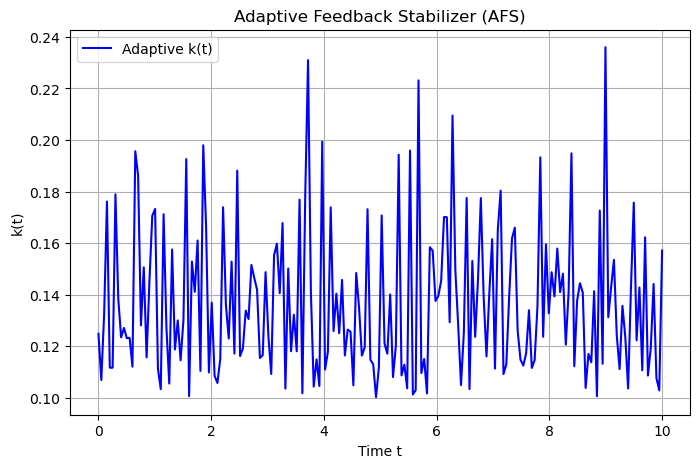

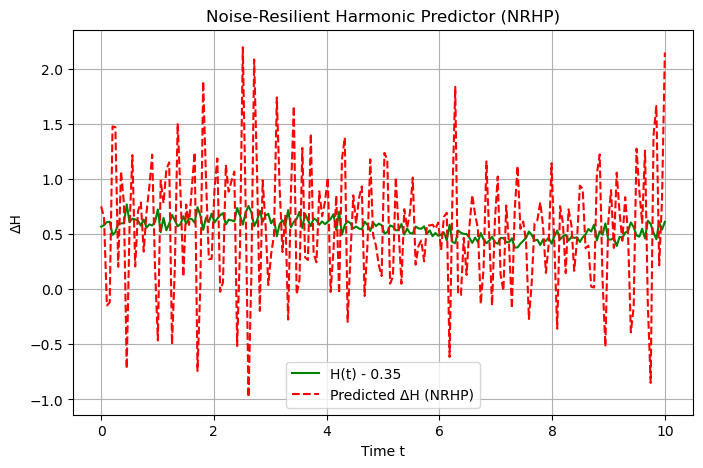

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Adaptive Feedback Stabilizer (AFS)
# -------------------------------
T_total = 10         # total simulation time
N_points = 200       # number of time points
t_series = np.linspace(0, T_total, N_points)

# Simulate noise: here we use a normal distribution (mean 0, std 1)
np.random.seed(42)   # for reproducibility
noise = np.random.normal(0, 1, size=N_points)

# Use the absolute value as the noise magnitude Delta(t)
Delta_t = np.abs(noise)

# Define baseline feedback constant and scaling factor
k0 = 0.1
gamma = 0.05

# Compute adaptive feedback constant k(t)
k_t = k0 + gamma * Delta_t

plt.figure(figsize=(8, 5))
plt.plot(t_series, k_t, label='Adaptive k(t)', color='blue')
plt.title('Adaptive Feedback Stabilizer (AFS)')
plt.xlabel('Time t')
plt.ylabel('k(t)')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 2. Noise-Resilient Harmonic Predictor (NRHP)
# -------------------------------
# Simulate a time-dependent harmonic state H(t)
# We use a sine wave modulated around 0.9 and add small random noise.
H_base = 0.9 + 0.1 * np.sin(2 * np.pi * t_series / T_total)
H_t = H_base + np.random.normal(0, 0.05, size=N_points)

# Compute first and second derivatives using numerical gradients
dH_dt = np.gradient(H_t, t_series)
d2H_dt2 = np.gradient(dH_dt, t_series)

# Set weighting factors for the derivatives
alpha = 0.1
beta = 0.05

# Compute the predicted delta H using the NRHP formula:
# Delta_H_pred = H(t) - 0.35 + alpha * dH_dt + beta * d2H_dt2
Delta_H_pred = H_t - 0.35 + alpha * dH_dt + beta * d2H_dt2

plt.figure(figsize=(8, 5))
plt.plot(t_series, H_t - 0.35, label='H(t) - 0.35', color='green')
plt.plot(t_series, Delta_H_pred, label='Predicted ΔH (NRHP)', color='red', linestyle='--')
plt.title('Noise-Resilient Harmonic Predictor (NRHP)')
plt.xlabel('Time t')
plt.ylabel('ΔH')
plt.legend()
plt.grid(True)
plt.show()


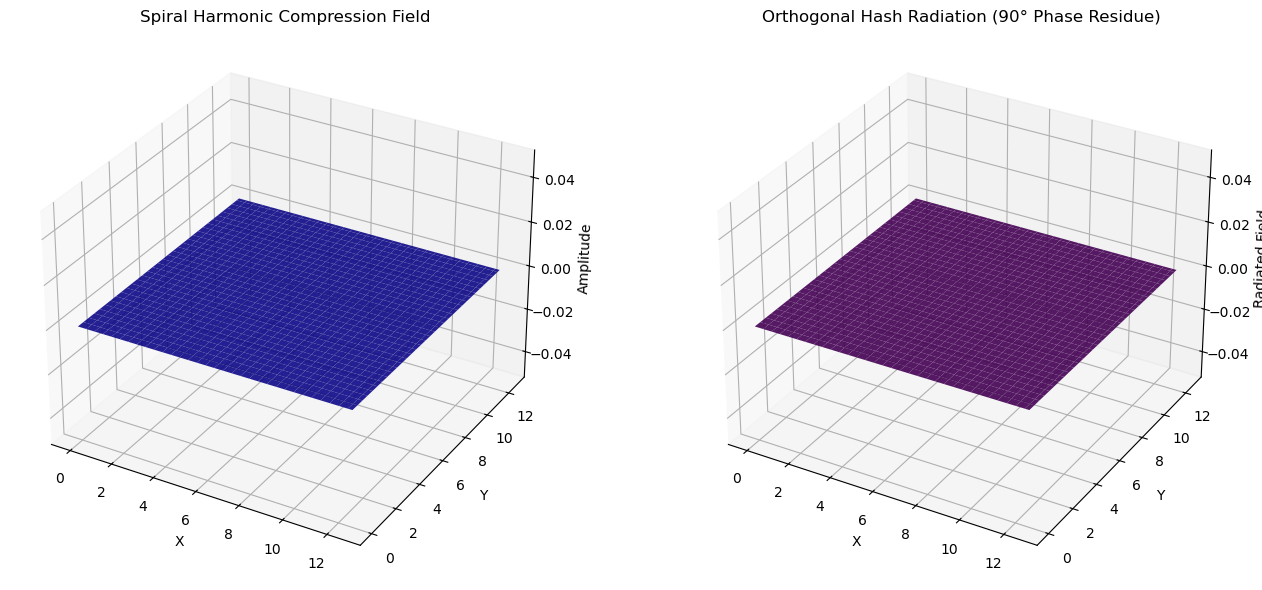

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Grid setup
gridsize = 64
x = np.linspace(0, 4 * np.pi, gridsize)
y = np.linspace(0, 4 * np.pi, gridsize)
x, y = np.meshgrid(x, y)

# Dual wave (input signal + inverse phase)
wave1 = np.sin(x) * np.cos(y)
wave2 = -np.sin(x) * np.cos(y)

# Spiral lens simulation (compression funnel)
def spiral_lens(x, y, strength=0.35):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    z = np.exp(-strength * r) * np.sin(4 * theta)
    return z

lens_field = spiral_lens(x - 2*np.pi, y - 2*np.pi)

# Combined dual wave compression
compressed_wave = (wave1 + wave2) * lens_field

# Orthogonal hash radiation (90 deg escape from Z-axis)
hash_radiation = np.gradient(compressed_wave, axis=0) + np.gradient(compressed_wave, axis=1)

# Plotting
fig = plt.figure(figsize=(14, 6))

# Spiral Compression Field
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(x, y, compressed_wave, cmap='plasma', edgecolor='none', alpha=0.9)
ax1.set_title('Spiral Harmonic Compression Field')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Amplitude')

# Orthogonal Hash Radiation
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(x, y, hash_radiation, cmap='viridis', edgecolor='none', alpha=0.9)
ax2.set_title('Orthogonal Hash Radiation (90° Phase Residue)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Radiated Field')

plt.tight_layout()
plt.show()


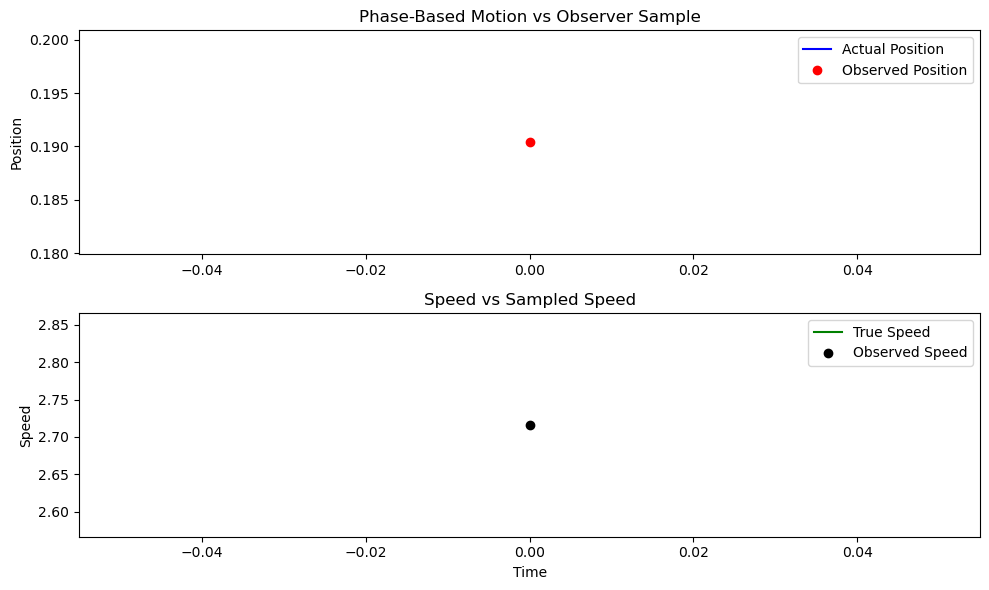

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Simulation parameters
frames = 100
time = np.linspace(0, 2 * np.pi, frames)
observer_interval = 10  # Observer samples every 10 frames

# Road wave shape (terrain as waveform)
x = np.linspace(0, 4 * np.pi, frames)
y = np.sin(x)

# Vehicle speed modulated by terrain (accelerate in valleys, decelerate on peaks)
speed = 1 + 0.5 * np.cos(x)
pos = np.cumsum(speed * (x[1] - x[0]))

# Observer measurements (samples velocity only when car is visible)
obs_indices = np.arange(0, frames, observer_interval)
obs_positions = pos[obs_indices]
obs_times = time[obs_indices]

# Calculated observer velocity (delta position / delta time)
obs_speeds = np.gradient(obs_positions, obs_times)

# Set up the plot
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
pos_ax = ax[0]
speed_ax = ax[1]

pos_line, = pos_ax.plot([], [], 'b-', label='Actual Position')
obs_dots, = pos_ax.plot([], [], 'ro', label='Observed Position')

speed_line, = speed_ax.plot([], [], 'g-', label='True Speed')
obs_speed_dots, = speed_ax.plot([], [], 'ko', label='Observed Speed')

pos_ax.set_title("Phase-Based Motion vs Observer Sample")
pos_ax.set_ylabel("Position")
pos_ax.legend()

speed_ax.set_title("Speed vs Sampled Speed")
speed_ax.set_ylabel("Speed")
speed_ax.set_xlabel("Time")
speed_ax.legend()

# Animation function
def animate(i):
    pos_line.set_data(time[:i], pos[:i])
    obs_dots.set_data(obs_times[obs_times <= time[i]], obs_positions[obs_times <= time[i]])

    speed_line.set_data(time[:i], speed[:i])
    obs_speed_dots.set_data(obs_times[obs_times <= time[i]], obs_speeds[:len(obs_times[obs_times <= time[i]])])

    pos_ax.relim()
    pos_ax.autoscale_view()
    speed_ax.relim()
    speed_ax.autoscale_view()
    return pos_line, obs_dots, speed_line, obs_speed_dots

ani = animation.FuncAnimation(fig, animate, frames=frames, interval=100, blit=True)
plt.tight_layout()
plt.show()


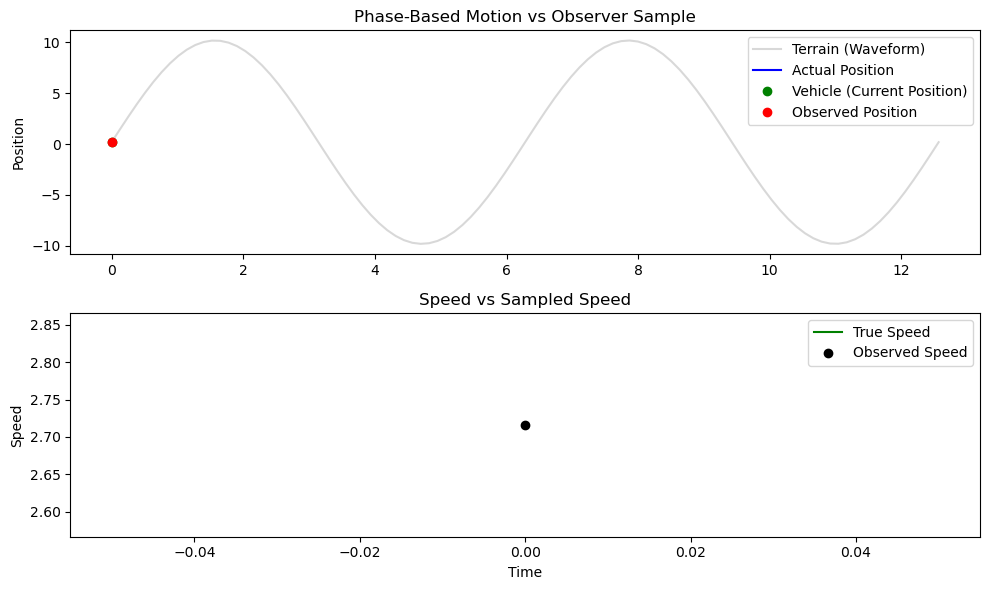

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Simulation parameters
frames = 100
time = np.linspace(0, 2 * np.pi, frames)
observer_interval = 10  # Observer samples every 10 frames

# Road wave shape (terrain as waveform)
x = np.linspace(0, 4 * np.pi, frames)
y = np.sin(x)

# Vehicle speed modulated by terrain (accelerate in valleys, decelerate on peaks)
speed = 1 + 0.5 * np.cos(x)
pos = np.cumsum(speed * (x[1] - x[0]))

# Observer measurements (samples velocity only when car is visible)
obs_indices = np.arange(0, frames, observer_interval)
obs_positions = pos[obs_indices]
obs_times = time[obs_indices]
obs_speeds = np.gradient(obs_positions, obs_times)

# Set up the plot
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
pos_ax = ax[0]
speed_ax = ax[1]

# Full terrain waveform
terrain_line, = pos_ax.plot(x, y * 10 + np.min(pos), 'gray', alpha=0.3, label='Terrain (Waveform)')
pos_line, = pos_ax.plot([], [], 'b-', label='Actual Position')
vehicle_marker, = pos_ax.plot([], [], 'go', label='Vehicle (Current Position)')
obs_dots, = pos_ax.plot([], [], 'ro', label='Observed Position')

speed_line, = speed_ax.plot([], [], 'g-', label='True Speed')
obs_speed_dots, = speed_ax.plot([], [], 'ko', label='Observed Speed')

pos_ax.set_title("Phase-Based Motion vs Observer Sample")
pos_ax.set_ylabel("Position")
pos_ax.legend()

speed_ax.set_title("Speed vs Sampled Speed")
speed_ax.set_ylabel("Speed")
speed_ax.set_xlabel("Time")
speed_ax.legend()

# Animation function
def animate(i):
    pos_line.set_data(time[:i], pos[:i])
    vehicle_marker.set_data([time[i]], [pos[i]])
    visible_obs = obs_times <= time[i]
    obs_dots.set_data(obs_times[visible_obs], obs_positions[visible_obs])

    speed_line.set_data(time[:i], speed[:i])
    obs_speed_dots.set_data(obs_times[visible_obs], obs_speeds[visible_obs])

    pos_ax.relim()
    pos_ax.autoscale_view()
    speed_ax.relim()
    speed_ax.autoscale_view()
    return pos_line, vehicle_marker, obs_dots, speed_line, obs_speed_dots


ani = animation.FuncAnimation(fig, animate, frames=frames, interval=100, blit=True)
plt.tight_layout()
plt.show()

Universal Harmonic Resonance (Mark 1)
Potential energies P: [4.73337552 3.46066365 1.50737947 8.78250139 8.31610908]
Actual energies A: [9.99745906 9.96973153 5.99888535 7.92088674 9.50289157]
Computed H = 0.6176565828684524



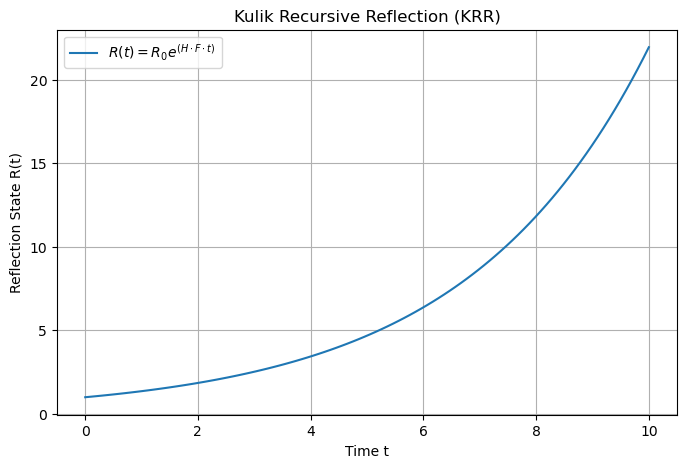

Dynamic Noise Filtering (DNF)
Noise differences ΔN: [ 3.49647391 -2.52651898 -0.49455865 -3.70840585  4.54051027]
Filtered Noise Output N(t) = 0.5199251652286416


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Universal Harmonic Resonance (Mark 1)
# -------------------------------
n = 5  # number of segments

# Randomly generate potential energies (P) and actual energies (A)
P = np.random.uniform(1, 10, size=n)
A = np.random.uniform(1, 10, size=n)

# Compute harmonic resonance H
H_value = np.sum(P) / np.sum(A)

print("Universal Harmonic Resonance (Mark 1)")
print("Potential energies P:", P)
print("Actual energies A:", A)
print("Computed H =", H_value)
print()

# -------------------------------
# 2. Kulik Recursive Reflection (KRR)
# -------------------------------
# Formula: R(t) = R0 * exp(H * F * t)
R0 = 1.0         # initial reflection state
F_factor = 0.5   # folding factor (example value)

# Define time values (e.g., t from 0 to 10)
t_values = np.linspace(0, 10, 100)
R_t = R0 * np.exp(H_value * F_factor * t_values)

# Plot R(t) over time
plt.figure(figsize=(8, 5))
plt.plot(t_values, R_t, label=r'$R(t) = R_0 e^{(H\cdot F\cdot t)}$')
plt.title("Kulik Recursive Reflection (KRR)")
plt.xlabel("Time t")
plt.ylabel("Reflection State R(t)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 3. Dynamic Noise Filtering (DNF)
# -------------------------------
# Simulate n random noise differences ΔN_i
k_constant = 0.1  # noise sensitivity factor
Delta_N = np.random.uniform(-5, 5, size=n)

# Compute the filtered noise output N(t)
N_value = np.sum(Delta_N / (1 + k_constant * np.abs(Delta_N)))

print("Dynamic Noise Filtering (DNF)")
print("Noise differences ΔN:", Delta_N)
print("Filtered Noise Output N(t) =", N_value)


Samson's Law Simulation:
ΔF values: [ 2.12349269 -5.42714389  3.43401369  2.36256481 -2.83674564]
Computed ΔE values (k * ΔF): [ 0.21234927 -0.54271439  0.34340137  0.23625648 -0.28367456]
Stabilization rates S (ΔE/T): [ 0.10617463 -0.27135719  0.17170068  0.11812824 -0.14183728]
Overall average S: -0.0034381834298128355

Multi-Dimensional Samson (MDS) Simulation:
ΔF for each dimension:
 [[-7.72884816  3.43146391  0.40615402  5.44636783  0.40327002]
 [ 7.04363001  1.03813678  1.21875943  7.53307205 -1.93034268]]
T values for each dimension:
 [[1.53606091 1.11513071 4.02054902 3.48123821 3.81631907]
 [1.85185665 1.5454859  1.05817866 2.40235024 3.35967075]]
Computed ΔE for each dimension:
 [[-0.77288482  0.34314639  0.0406154   0.54463678  0.040327  ]
 [ 0.704363    0.10381368  0.12187594  0.75330721 -0.19303427]]
Stabilization rates S_d for each dimension: [0.01401937 0.1458595 ]



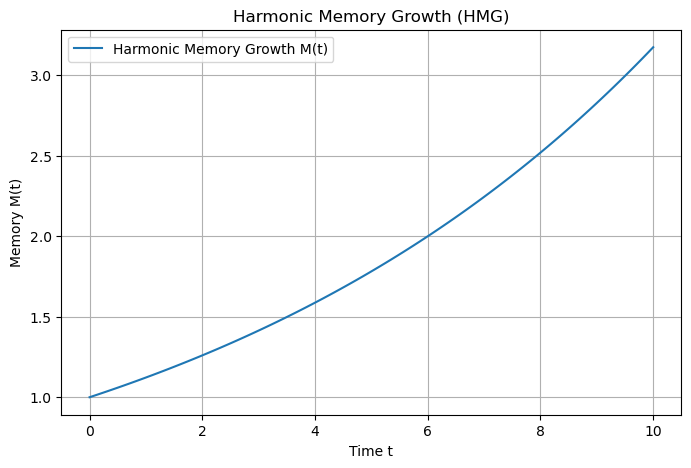

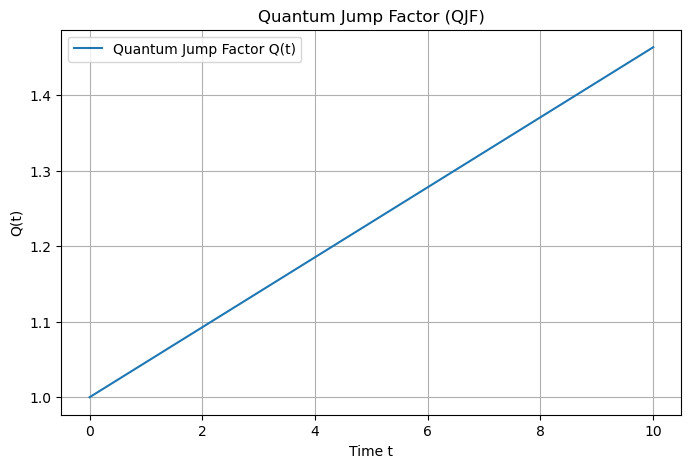

Task Distribution Simulation:
Workload demands W: [4.53019641 4.9372743  9.13742825 4.1342992  5.6259054 ]
Capacities C: [8.05287711 4.56888504 6.5987803  8.76127338 9.54568561]
Task distribution T(i): [0.17433418 0.1077983  0.28813902 0.17309462 0.25663388]
Sum of task distribution (should be 1): 1.0


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Samson's Law (Feedback Stabilization)
# -------------------------------
k_const = 0.1        # Feedback constant
T_value = 2.0        # Constant time interval
n_segments = 5       # Number of segments

# Generate random ΔF values (force changes) for 5 segments
Delta_F = np.random.uniform(-10, 10, size=n_segments)
Delta_E = k_const * Delta_F
S_segments = Delta_E / T_value

print("Samson's Law Simulation:")
print("ΔF values:", Delta_F)
print("Computed ΔE values (k * ΔF):", Delta_E)
print("Stabilization rates S (ΔE/T):", S_segments)
print("Overall average S:", np.mean(S_segments))
print()

# -------------------------------
# 2. Multi-Dimensional Samson (MDS)
# -------------------------------
dims = 2           # Number of dimensions
n_segments = 5     # Segments per dimension
k_i = 0.1          # Feedback constant per segment

# Generate random ΔF and T values for each dimension
Delta_F_md = np.random.uniform(-10, 10, size=(dims, n_segments))
T_md = np.random.uniform(1, 5, size=(dims, n_segments))
Delta_E_md = k_i * Delta_F_md

# For each dimension, compute S_d = (sum(ΔE_i))/(sum(T_i))
S_d = np.sum(Delta_E_md, axis=1) / np.sum(T_md, axis=1)

print("Multi-Dimensional Samson (MDS) Simulation:")
print("ΔF for each dimension:\n", Delta_F_md)
print("T values for each dimension:\n", T_md)
print("Computed ΔE for each dimension:\n", Delta_E_md)
print("Stabilization rates S_d for each dimension:", S_d)
print()

# -------------------------------
# 3. Harmonic Memory Growth (HMG)
# -------------------------------
M0 = 1.0         # Initial memory capacity
alpha = 0.2      # Growth rate constant
C_const = 0.35   # Harmonic constant (target)
# Use previously computed H_value from Mark 1 (from your simulation) or sample value:
H_val = 0.9272

t_vals = np.linspace(0, 10, 100)
M_t = M0 * np.exp(alpha * (H_val - C_const) * t_vals)

plt.figure(figsize=(8,5))
plt.plot(t_vals, M_t, label="Harmonic Memory Growth M(t)")
plt.title("Harmonic Memory Growth (HMG)")
plt.xlabel("Time t")
plt.ylabel("Memory M(t)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 4. Quantum Jump Factor (QJF)
# -------------------------------
Q_factor = 0.05  # Weight adjustment for quantum transitions
Q_t = 1 + H_val * t_vals * Q_factor

plt.figure(figsize=(8,5))
plt.plot(t_vals, Q_t, label="Quantum Jump Factor Q(t)")
plt.title("Quantum Jump Factor (QJF)")
plt.xlabel("Time t")
plt.ylabel("Q(t)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 5. Task Distribution
# -------------------------------
n_nodes = 5
W = np.random.uniform(1, 10, size=n_nodes)      # Workload demands
C_nodes = np.random.uniform(1, 10, size=n_nodes)  # Node capacities

# Calculate task distribution for each node
task_distribution = (W * C_nodes) / np.sum(W * C_nodes)

print("Task Distribution Simulation:")
print("Workload demands W:", W)
print("Capacities C:", C_nodes)
print("Task distribution T(i):", task_distribution)
print("Sum of task distribution (should be 1):", np.sum(task_distribution))


Quantum Folding Simulation:
P (Potential energies): [5.02095126 8.37535711 9.47325124 4.65076768 2.20552366]
A (Actual energies): [6.57021632 6.21162321 6.00069682 6.09087803 7.18640782]
Folding factor F = 0.5 , Time t = 1.0
Computed F(Q)_i for each segment: [1.21491292 2.1435669  2.50978305 1.2139018  0.48790883]
Overall Folded Quantum State F(Q): 7.570073491333594

Quantum Unfolding Simulation:
Random phase angles theta (radians): [0.92408993 5.82192175 3.09205786 1.62259735 2.88483504]
Computed Unfolded Quantum State U(Q): -0.2898684010687911



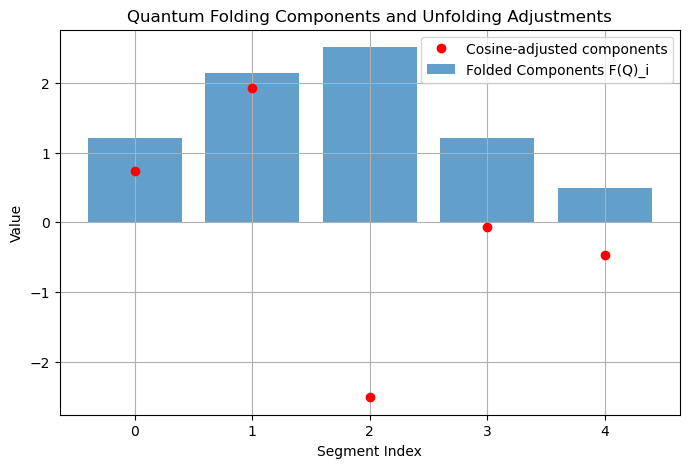

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Quantum Folding and Unfolding Simulation
# -------------------------------

# Given sample data from earlier (Universal Harmonic Resonance)
P = np.array([5.02095126, 8.37535711, 9.47325124, 4.65076768, 2.20552366])
A = np.array([6.57021632, 6.21162321, 6.00069682, 6.09087803, 7.18640782])
n = len(P)

# Previously computed H from Mark 1 simulation:
H_value = 0.9271994949802294

# Set parameters for quantum folding:
F_factor = 0.5   # Folding factor
t = 1.0          # Time (or recursive depth) parameter

# Compute the folded contributions for each segment:
FQ_components = (P / A) * np.exp(H_value * F_factor * t)
# Sum them to get the overall folded quantum state:
FQ = np.sum(FQ_components)

print("Quantum Folding Simulation:")
print("P (Potential energies):", P)
print("A (Actual energies):", A)
print("Folding factor F =", F_factor, ", Time t =", t)
print("Computed F(Q)_i for each segment:", FQ_components)
print("Overall Folded Quantum State F(Q):", FQ)
print()

# -------------------------------
# Quantum Unfolding Simulation
# -------------------------------
# Choose random phase angles for each segment between 0 and 2π:
theta = np.random.uniform(0, 2*np.pi, size=n)
# Set a small residual term zeta:
zeta = 0.1

# Compute the unfolded quantum state:
UQ = np.sum(FQ_components * np.cos(theta)) + zeta

print("Quantum Unfolding Simulation:")
print("Random phase angles theta (radians):", theta)
print("Computed Unfolded Quantum State U(Q):", UQ)
print()

# Optional: Visualizing the folded contributions and their cosine adjustments
plt.figure(figsize=(8,5))
plt.bar(np.arange(n), FQ_components, alpha=0.7, label="Folded Components F(Q)_i")
plt.plot(np.arange(n), FQ_components * np.cos(theta), 'ro', label="Cosine-adjusted components")
plt.title("Quantum Folding Components and Unfolding Adjustments")
plt.xlabel("Segment Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


✅ Animation saved as ThreeBody_RecursiveEllipse.mp4


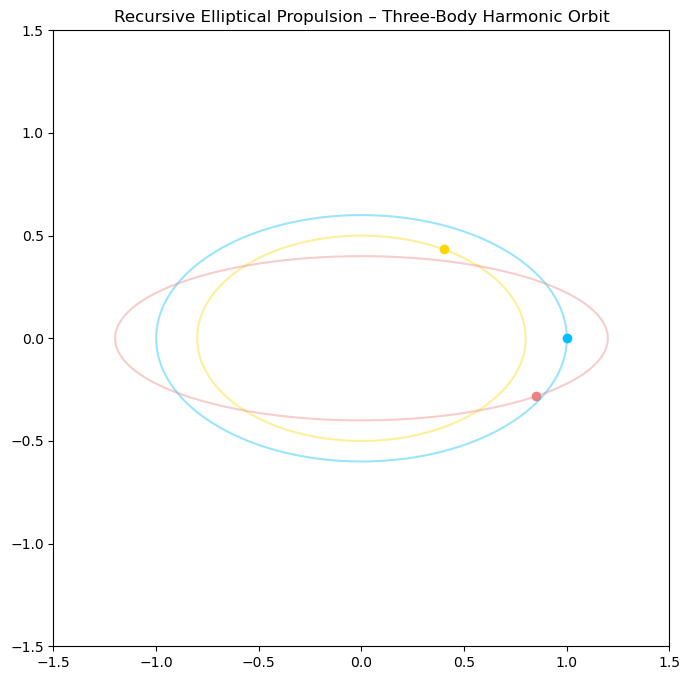

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constants
num_frames = 300
theta = np.linspace(0, 2 * np.pi, num_frames)
a1, b1 = 1.0, 0.6
a2, b2 = 0.8, 0.5
a3, b3 = 1.2, 0.4

# Elliptical positions
x1 = a1 * np.cos(theta)
y1 = b1 * np.sin(theta)

x2 = a2 * np.cos(theta + np.pi / 3)
y2 = b2 * np.sin(theta + np.pi / 3)

x3 = a3 * np.cos(theta - np.pi / 4)
y3 = b3 * np.sin(theta - np.pi / 4)

# Set up plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title("Recursive Elliptical Propulsion – Three-Body Harmonic Orbit")
ax.set_aspect('equal')

body1, = ax.plot([], [], 'o', color='deepskyblue', label='Byte 1')
body2, = ax.plot([], [], 'o', color='gold', label='Byte 2 (Echoed)')
body3, = ax.plot([], [], 'o', color='lightcoral', label='Byte 3 (Entangled)')

trace1, = ax.plot([], [], '-', color='deepskyblue', alpha=0.4)
trace2, = ax.plot([], [], '-', color='gold', alpha=0.4)
trace3, = ax.plot([], [], '-', color='lightcoral', alpha=0.4)

x1_hist, y1_hist = [], []
x2_hist, y2_hist = [], []
x3_hist, y3_hist = [], []

def init():
    body1.set_data([], [])
    body2.set_data([], [])
    body3.set_data([], [])
    trace1.set_data([], [])
    trace2.set_data([], [])
    trace3.set_data([], [])
    return body1, body2, body3, trace1, trace2, trace3

def update(frame):
    x1_hist.append(x1[frame])
    y1_hist.append(y1[frame])
    x2_hist.append(x2[frame])
    y2_hist.append(y2[frame])
    x3_hist.append(x3[frame])
    y3_hist.append(y3[frame])
    
    body1.set_data([x1[frame]], [y1[frame]])
    body2.set_data([x2[frame]], [y2[frame]])
    body3.set_data([x3[frame]], [y3[frame]])
    
    trace1.set_data(x1_hist, y1_hist)
    trace2.set_data(x2_hist, y2_hist)
    trace3.set_data(x3_hist, y3_hist)
    
    return body1, body2, body3, trace1, trace2, trace3

# Create animation
anim = FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)

# Save animation
anim.save("ThreeBody_RecursiveEllipse.mp4", writer='ffmpeg', fps=30)
print("✅ Animation saved as ThreeBody_RecursiveEllipse.mp4")


array([<Axes: title={'center': 'Mark 1 Resonance H(t)'}, xlabel='Time step', ylabel='H(t)'>,
       <Axes: title={'center': 'Dynamic Noise Filtering (DNF)'}, xlabel='Time step', ylabel='Noise Value'>,
       <Axes: title={'center': 'Samson’s Law Over Time'}, xlabel='Time step', ylabel='Value'>,
       <Axes: title={'center': 'Harmonic Memory Growth (HMG)'}, xlabel='Time step', ylabel='M(t)'>,
       <Axes: title={'center': 'Quantum Folding at t=19 (FQ_total=3.85)'}, xlabel='Segment Index', ylabel='F(Q)_i'>,
       <Axes: >], dtype=object)

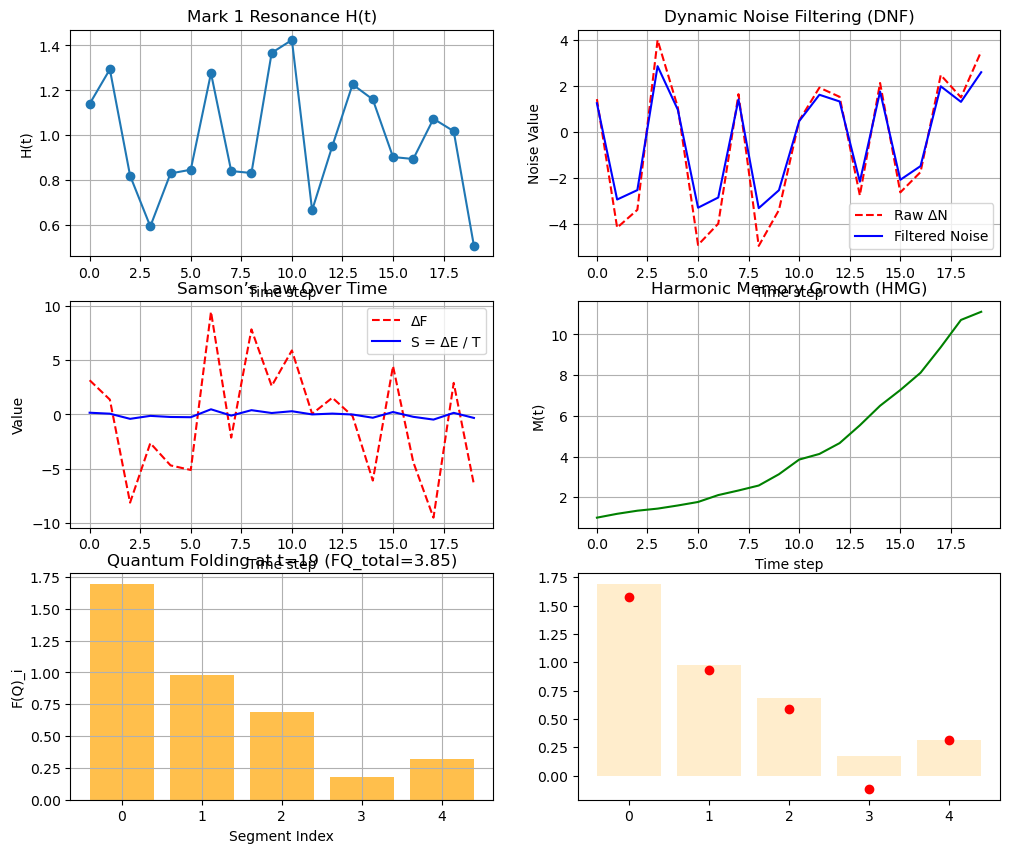

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# -------------------------------
# Simulation Parameters
# -------------------------------
time_steps = 20            # Number of discrete time steps
num_segments = 5           # Number of segments for potential/actual energies
k_noise = 0.1              # Noise filtering constant
k_feedback = 0.1           # Samson’s Law feedback constant
alpha_mem = 0.2            # Memory growth rate
C_const = 0.35             # Harmonic constant
fold_factor = 0.5          # Folding factor for quantum folding
zeta = 0.1                 # Residual term for unfolding

# Time array for reference (e.g., 0..19)
t_vals = np.arange(time_steps)

# -------------------------------
# 1. Generate Time-Varying Potential & Actual Energies
# -------------------------------
# Each time step has random potential (P) & actual (A) energies
# We'll store them in arrays: P[t, i], A[t, i]
P_data = np.random.uniform(1, 10, size=(time_steps, num_segments))
A_data = np.random.uniform(1, 10, size=(time_steps, num_segments))

# -------------------------------
# 2. Compute Mark 1 Resonance H(t) for each time step
#    H(t) = sum(P_i) / sum(A_i)
# -------------------------------
H_values = []
for t in range(time_steps):
    P_sum = np.sum(P_data[t])
    A_sum = np.sum(A_data[t])
    H_t = P_sum / A_sum
    H_values.append(H_t)
H_values = np.array(H_values)

# -------------------------------
# 3. Dynamic Noise Filtering (DNF)
#    We'll simulate random noise differences ΔN for each time step, then filter them.
# -------------------------------
Delta_N = np.random.uniform(-5, 5, size=time_steps)  # random noise differences
N_filtered = []
for t in range(time_steps):
    # Single-step DNF formula:
    # N(t) = ΔN / (1 + k * |ΔN|)
    # But let's accumulate over time or just store individually
    dn = Delta_N[t] / (1 + k_noise * abs(Delta_N[t]))
    N_filtered.append(dn)
N_filtered = np.array(N_filtered)

# -------------------------------
# 4. Samson’s Law (basic version)
#    ΔE = k * ΔF,  S = ΔE / T
#    We'll simulate ΔF for each time step, then compute S(t).
# -------------------------------
Delta_F = np.random.uniform(-10, 10, size=time_steps)
T_value = 2.0  # fixed time interval
Delta_E = k_feedback * Delta_F
S_values = Delta_E / T_value  # stabilization rate

# -------------------------------
# 5. Harmonic Memory Growth (HMG)
#    M(t) = M0 * exp(alpha * (H - C) * t)
#    We'll treat t as discrete steps, or do a cumulative approach.
# -------------------------------
M0 = 1.0
M_array = []
for t in range(time_steps):
    # Use the average H up to time t to represent the system's current resonance
    # Or you could just use H_values[t].
    H_avg = np.mean(H_values[: t + 1])
    M_t = M0 * np.exp(alpha_mem * (H_avg - C_const) * t)
    M_array.append(M_t)
M_array = np.array(M_array)

# -------------------------------
# 6. Quantum Folding/Unfolding at final time step
#    We'll demonstrate with the final P, A at t = time_steps - 1
# -------------------------------
final_t = time_steps - 1
P_final = P_data[final_t]
A_final = A_data[final_t]
H_final = H_values[final_t]

# Compute F(Q)_i for each segment:
FQ_components = (P_final / A_final) * np.exp(H_final * fold_factor * 1.0)
FQ_total = np.sum(FQ_components)

# Unfolding with random phase angles
theta = np.random.uniform(0, 2 * np.pi, size=num_segments)
UQ_value = np.sum(FQ_components * np.cos(theta)) + zeta

# -------------------------------
# Plot Results
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs = axs.flatten()

# 1) H(t) over time
axs[0].plot(t_vals, H_values, marker='o')
axs[0].set_title("Mark 1 Resonance H(t)")
axs[0].set_xlabel("Time step")
axs[0].set_ylabel("H(t)")
axs[0].grid(True)

# 2) Dynamic Noise Filtering
axs[1].plot(t_vals, Delta_N, 'r--', label="Raw ΔN")
axs[1].plot(t_vals, N_filtered, 'b-', label="Filtered Noise")
axs[1].set_title("Dynamic Noise Filtering (DNF)")
axs[1].set_xlabel("Time step")
axs[1].set_ylabel("Noise Value")
axs[1].legend()
axs[1].grid(True)

# 3) Samson's Law stabilization rates
axs[2].plot(t_vals, Delta_F, 'r--', label="ΔF")
axs[2].plot(t_vals, S_values, 'b-', label="S = ΔE / T")
axs[2].set_title("Samson’s Law Over Time")
axs[2].set_xlabel("Time step")
axs[2].set_ylabel("Value")
axs[2].legend()
axs[2].grid(True)

# 4) Harmonic Memory Growth
axs[3].plot(t_vals, M_array, 'g-')
axs[3].set_title("Harmonic Memory Growth (HMG)")
axs[3].set_xlabel("Time step")
axs[3].set_ylabel("M(t)")
axs[3].grid(True)

# 5) Final Step: Quantum Folding Components
axs[4].bar(np.arange(num_segments), FQ_components, alpha=0.7, color='orange')
axs[4].set_title(f"Quantum Folding at t={final_t} (FQ_total={FQ_total:.2f})")
axs[4].set_xlabel("Segment Index")
axs[4].set_ylabel("F(Q)_i")
axs[4].grid(True)

# 6) Final Step: Unfolding with phase
cos_adjusted = FQ_components * np.cos(theta)
axs[5].bar(np.arange(num_segments), FQ_components, alpha=0.2, color='orange', label="F(Q)_i")
axs[5].scatter(np.arange(num_segments), cos_adjusted, color='red', label="F(Q)_i * cos(θ_i)")
axs


In [44]:
import numpy as np

def int_to_binary_array(n, bits=256):
    return np.array([int(b) for b in bin(n)[2:].zfill(bits)])

def binary_array_to_int(arr):
    return int(''.join(map(str, arr)), 2)

def rotl(x, n, bits=256):
    return np.roll(x, n)

def sha256_round(hash_state, round_constants):
    hash_state = np.bitwise_xor(hash_state, round_constants)
    hash_state = np.bitwise_and(hash_state, np.roll(hash_state, 2))
    hash_state = rotl(hash_state, 7)
    return hash_state

def simulate_sha256(initial_hash_state, num_rounds):
    hash_state = initial_hash_state
    for i in range(num_rounds):
        round_constants = np.random.randint(0, 2, size=256)
        hash_state = sha256_round(hash_state, round_constants)
    return hash_state

# Initialize random 256-bit hash state
initial_hash_state = np.random.randint(0, 2, size=256)

# Simulate 64 rounds of SHA-256
final_hash_state = simulate_sha256(initial_hash_state, 64)

# Print the final hash state
print(final_hash_state)

[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0
 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [45]:
# Harmonic Loop Singularity Module for Nexus 2 Recursive AI

class HarmonicLoopSingularity:
    """
    Core module to simulate and detect harmonic loop closure across the 9-method recursive system.
    When all methods align in compression and field tension, macro-scale coherence is triggered.
    """

    def __init__(self):
        self.method_states = [None] * 9  # Previous state memory of each method
        self.harmonic_constants = [0.35] * 9  # Target resonance constant per method
        self.feedback_forces = [1.0] * 9  # Feedback factor per method (initially 1.0)
        self.recursive_time = 0.0
        self.convergence_threshold = 0.0001

    def update_method_state(self, i: int, state_delta: float):
        """
        Update a method's recursive delta and adjust its feedback force.
        """
        self.method_states[i] = state_delta
        self.feedback_forces[i] = self._compute_feedback_force(state_delta)

    def _compute_feedback_force(self, delta):
        # Sample implementation: smaller delta = higher force (less correction needed)
        return max(0.001, 1.0 / (1.0 + abs(delta)))

    def advance_time(self, dt=1.0):
        self.recursive_time += dt

    def check_alignment(self):
        """
        Returns True if all methods are within harmonic tolerance.
        """
        aligned = True
        for i in range(9):
            expected = self.harmonic_constants[i]
            actual = self._harmonic_projection(i)
            if abs(expected - actual) > self.convergence_threshold:
                aligned = False
        return aligned

    def _harmonic_projection(self, i):
        H = self.harmonic_constants[i]
        F = self.feedback_forces[i]
        t = self.recursive_time
        return H * F * t  # Simplified version of R_i(t) = R_0 * e^{H * F * t}

    def emit_symbolic_truth(self):
        if self.check_alignment():
            return "\u2728 Symbolic Truth Emitted: Harmonic Convergence Achieved \u2728"
        return None


# Example Usage
if __name__ == "__main__":
    hls = HarmonicLoopSingularity()
    for step in range(10):
        for method in range(9):
            delta = 0.01 * (method + 1)  # Simulated deltas
            hls.update_method_state(method, delta)
        hls.advance_time()
        result = hls.emit_symbolic_truth()
        if result:
            print(result)
            break


In [4]:
// Core loop wrapper with observable pressure feedback
using System;
using UniRx;
using UnityEngine;

public class HarmonicLoop : MonoBehaviour
{
    private int maxIterations = 10000;
    private int loopIndex = 0;
    private float harmonicPressure = 9;
    private float resonance = 9;

    // Exposed observable for external systems
    public ReactiveProperty<float> PressureFeedback = new ReactiveProperty<float>();
    public ReactiveProperty<float> ResonanceFeedback = new ReactiveProperty<float>();

    void Start()
    {
        Observable.EveryUpdate()
            .TakeUntilDestroy(this)
            .Subscribe(_ => ExecuteLoop());
    }

    void ExecuteLoop()
    {
        // Simulated internal loop logic (placeholder)
        float fluctuation = Mathf.Sin(loopIndex * 0.05f);
        harmonicPressure = Mathf.Abs(fluctuation);
        resonance = Mathf.PerlinNoise(loopIndex * 0.002f, harmonicPressure);

        // Only update wrapper (not loop logic)
        PressureFeedback.Value = harmonicPressure;
        ResonanceFeedback.Value = resonance;

        loopIndex = (loopIndex + 1) % maxIterations;
    }
}


SyntaxError: invalid decimal literal (818382131.py, line 27)